 ### 1) Import Libraries & SetUp

In [58]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing
from collections import Counter

# For NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# For ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download stopwords (first time only)
nltk.download('stopwords')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250', 'axes.labelcolor': '#c8cfe8',
    'axes.titlecolor': '#ffffff', 'xtick.color': '#8890b0',
    'ytick.color': '#8890b0', 'text.color': '#c8cfe8',
    'grid.color': '#2e3250', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})

PALETTE = ['#4f8ef7','#f7a24f','#4ff7a2','#f74f8e','#a24ff7','#f7f74f','#4ff7f7']
DARK_BG = '#0f1117'


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HELAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


2) Know your data

In [59]:
df = pd.read_csv("../Data/resume_job_matching_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (10000, 3)


,job_description,resume,match_score
0,"Data Analyst needed with experience in SQL, Ex...","Experienced professional skilled in SQL, Power...",4
1,Data Scientist needed with experience in Stati...,"Experienced professional skilled in Python, De...",4
2,Software Engineer needed with experience in Sy...,"Experienced professional skilled in wait, Git,...",5
3,"ML Engineer needed with experience in Python, ...","Experienced professional skilled in return, De...",4
4,Software Engineer needed with experience in RE...,"Experienced professional skilled in REST APIs,...",5


In [60]:
print(df.columns)

Index(['job_description', 'resume', 'match_score'], dtype='str')


- Data Cleaning And Preprocessing

In [61]:
from preprocessing import clean_text

#  Apply cleaning to resume and job_description columns
df["Cleaned_Resume"] = df["resume"].apply(clean_text)
df["Cleaned_JD"] = df["job_description"].apply(clean_text)

# Preview cleaned columns
df[["resume", "Cleaned_Resume", "job_description", "Cleaned_JD"]].head()

,resume,Cleaned_Resume,job_description,Cleaned_JD
0,"Experienced professional skilled in SQL, Power...",experienced professional skilled sql power bi ...,"Data Analyst needed with experience in SQL, Ex...",data analyst needed experience sql excel power...
1,"Experienced professional skilled in Python, De...",experienced professional skilled python deep l...,Data Scientist needed with experience in Stati...,data scientist needed experience statistics pa...
2,"Experienced professional skilled in wait, Git,...",experienced professional skilled wait git syst...,Software Engineer needed with experience in Sy...,software engineer needed experience system des...
3,"Experienced professional skilled in return, De...",experienced professional skilled return democr...,"ML Engineer needed with experience in Python, ...",ml engineer needed experience python computer ...
4,"Experienced professional skilled in REST APIs,...",experienced professional skilled rest apis agi...,Software Engineer needed with experience in RE...,software engineer needed experience rest apis ...


- Missing Values Check

In [62]:
print(df.isnull().sum())

job_description    0
resume             0
match_score        0
Cleaned_Resume     0
Cleaned_JD         0
dtype: int64


- Duplicate Rows Check

In [63]:
print(df.duplicated().sum())

0


- Data Types

In [64]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_description  10000 non-null  str  
 1   resume           10000 non-null  str  
 2   match_score      10000 non-null  int64
 3   Cleaned_Resume   10000 non-null  str  
 4   Cleaned_JD       10000 non-null  str  
dtypes: int64(1), str(4)
memory usage: 390.8 KB
None


- Match Score Balance

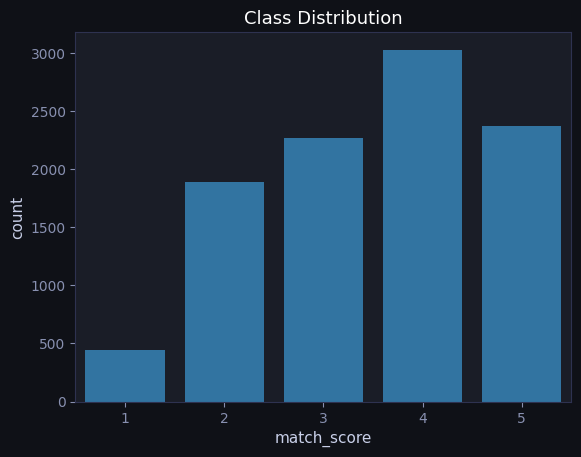

In [67]:
df["resume_length"] = df["Cleaned_Resume"].apply(lambda x: len(x.split()))
df["jd_length"] = df["Cleaned_JD"].apply(lambda x: len(x.split()))

sns.countplot(x=df["match_score"])
plt.title("Class Distribution")
plt.show()

- Resume Length vs Score

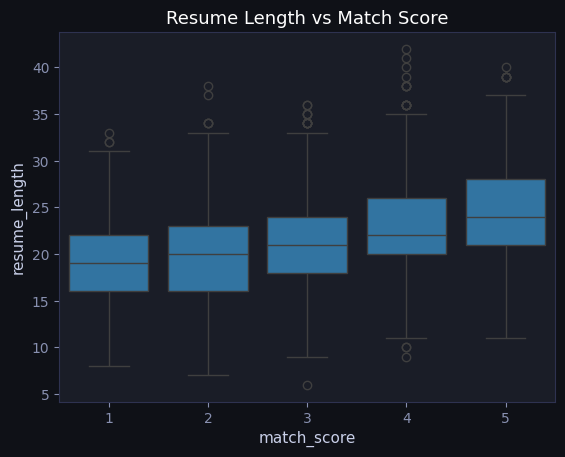

In [68]:

sns.boxplot(x="match_score", y="resume_length", data=df)
plt.title("Resume Length vs Match Score")
plt.show()

- Job Description Length vs Score

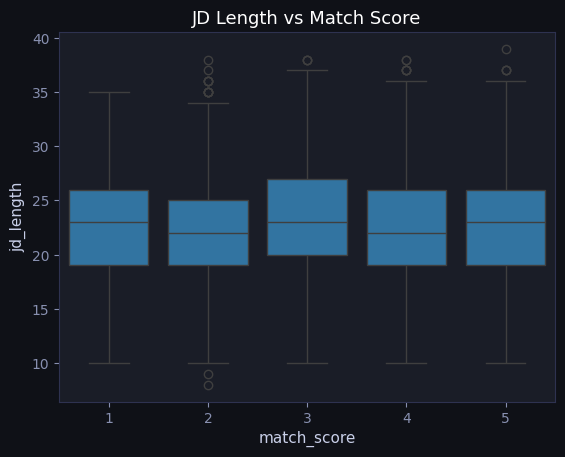

In [69]:
sns.boxplot(x="match_score", y="jd_length", data=df)
plt.title("JD Length vs Match Score")
plt.show()

- Correlation

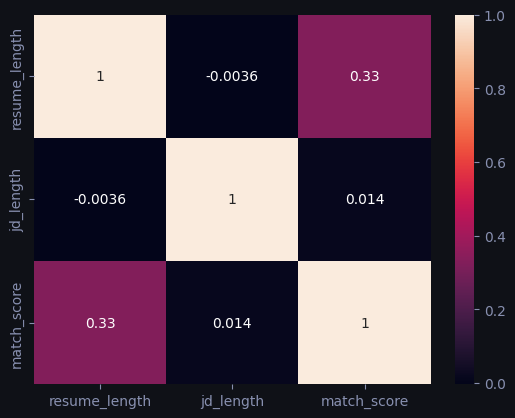

In [70]:
df[["resume_length","jd_length","match_score"]].corr()
sns.heatmap(df[["resume_length","jd_length","match_score"]].corr(), annot=True)
plt.show()

- Outliers

<Axes: ylabel='resume_length'>

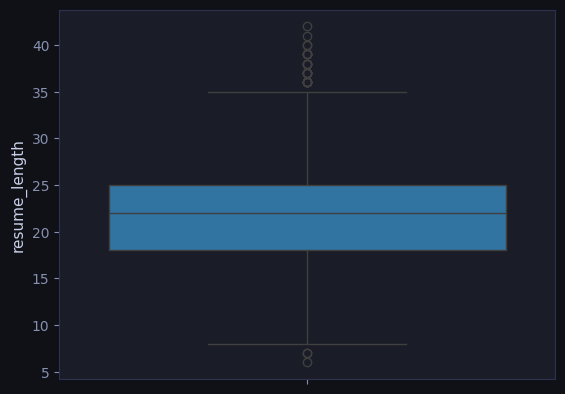

In [71]:
sns.boxplot(df["resume_length"])

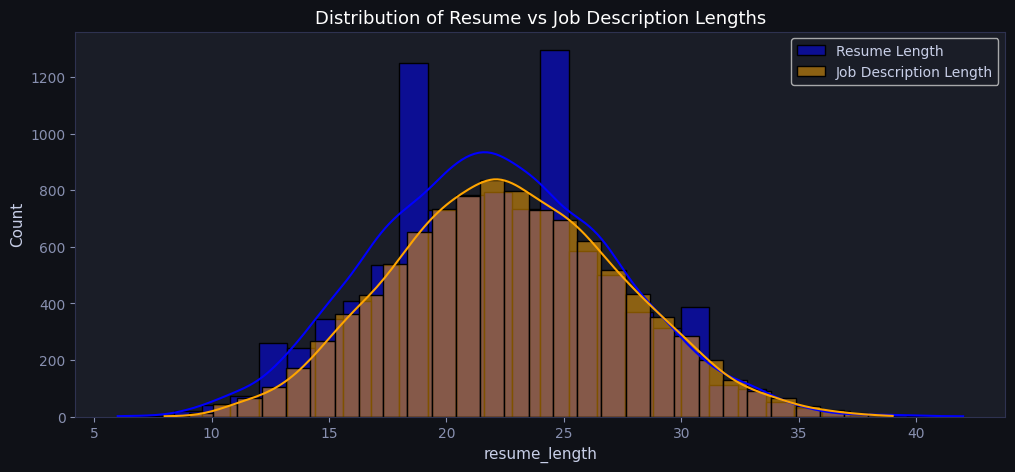

C:\Users\HELAL\AppData\Local\Temp\ipykernel_14976\2573459837.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="magma")


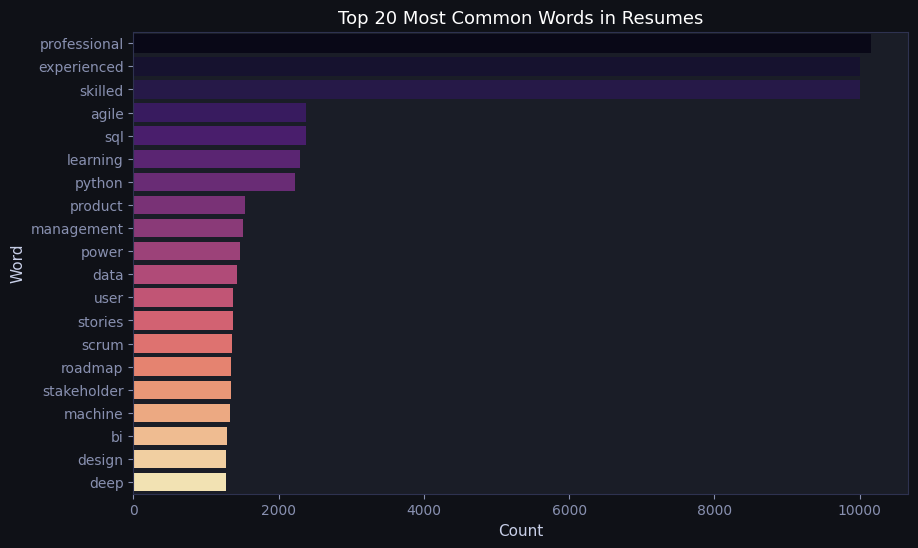

C:\Users\HELAL\AppData\Local\Temp\ipykernel_14976\2573459837.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


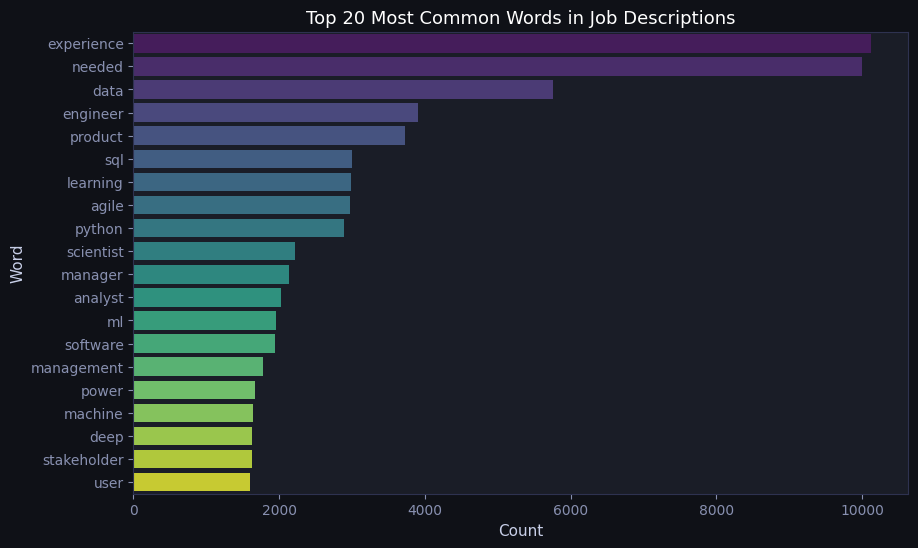

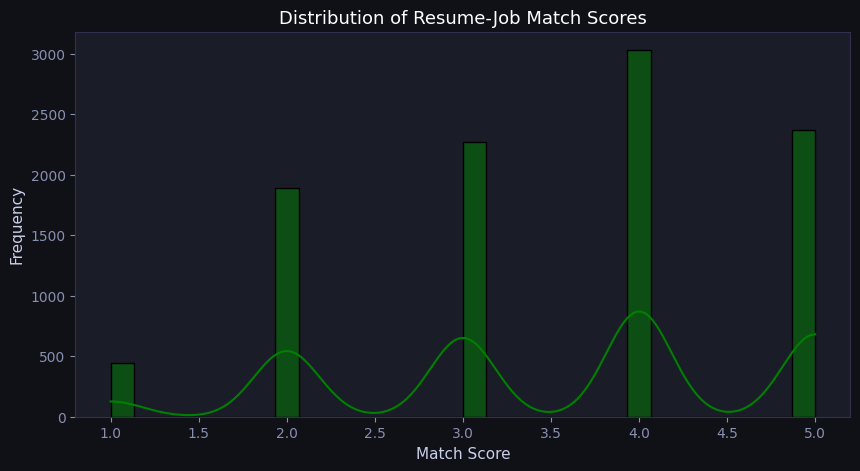

In [72]:
# 6.1 Resume vs JD length distributions
df["resume_length"] = df["Cleaned_Resume"].apply(lambda x: len(x.split()))
df["jd_length"] = df["Cleaned_JD"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12,5))
sns.histplot(df["resume_length"], bins=30, kde=True, color="blue", label="Resume Length")
sns.histplot(df["jd_length"], bins=30, kde=True, color="orange", label="Job Description Length")
plt.legend()
plt.title("Distribution of Resume vs Job Description Lengths")
plt.show()

# 6.2 Top 20 most common words in resumes
all_resume_text = " ".join(df["Cleaned_Resume"].astype(str).tolist())
resume_counts = Counter(all_resume_text.split()).most_common(20)

words, counts = zip(*resume_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Most Common Words in Resumes")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.3 Top 20 most common words in job descriptions
all_jd_text = " ".join(df["Cleaned_JD"].astype(str).tolist())
jd_counts = Counter(all_jd_text.split()).most_common(20)

words, counts = zip(*jd_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Most Common Words in Job Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.4 Match score distribution
plt.figure(figsize=(10,5))
sns.histplot(df["match_score"], bins=30, kde=True, color="green")
plt.title("Distribution of Resume-Job Match Scores")
plt.xlabel("Match Score")
plt.ylabel("Frequency")
plt.show()


- TF-IDF Vectorization

In [73]:
from preprocessing import clean_text
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure stopwords are downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Clean resumes
df["combined_text"] = df["Cleaned_Resume"] + " " + df["Cleaned_JD"]

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1500)

X_tfidf = tfidf_vectorizer.fit_transform(df["combined_text"])
y = df["match_score"]  # or whichever column represents the category/score

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of TF-IDF matrix:", X_tfidf.shape)
print("Sample TF-IDF features:", tfidf_vectorizer.get_feature_names_out()[:10])


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HELAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of TF-IDF matrix: (10000, 904)
Sample TF-IDF features: ['ability' 'able' 'accept' 'according' 'account' 'across' 'act' 'action'
 'activity' 'actually']


- Train LightGBM Model

In [74]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 81617
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 904
[LightGBM] [Info] Start training from score -3.123566
[LightGBM] [Info] Start training from score -1.666008
[LightGBM] [Info] Start training from score -1.483356
[LightGBM] [Info] Start training from score -1.194435
[LightGBM] [Info] Start training from score -1.438641
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


- Prediction

In [75]:
y_pred = model.predict(X_test)

c:\Users\HELAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


- Metrics

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.5765
Precision: 0.5799774363205521
Recall   : 0.5765
F1 Score : 0.5695191387969121


-  Saving Model

In [77]:
import joblib

# Save a model
joblib.dump(model, "../models/model.pkl")

# Later, to load it
loaded_model = joblib.load("../models/model.pkl")

- Resume vs Job Requirements 

In [81]:
import PyPDF2

# --- 1. Average Fresher Job Requirement for ML/Data Science ---
job_req = """
Programming: Python, SQL
Machine Learning: scikit-learn, SVM, Random Forest, Logistic Regression, K-Means, Decision Trees
Data Analysis & Visualization: NumPy, Pandas, Matplotlib, Seaborn
Data Preprocessing: Feature Engineering, Data Cleaning, Handling Missing Values
Model Evaluation: Accuracy, Precision, Recall, F1-score
Tools: Git, GitHub, Jupyter Notebook, Google Colab
Soft Skills: Problem Solving, Analytical Thinking, Communication
"""

# 2. Read PDF from folder
resume_path = "../Resume/Resume.pdf"

resume_text = ""
with open(resume_path, "rb") as f:
    reader = PyPDF2.PdfReader(f)
    for page in reader.pages:
        resume_text += page.extract_text()

# 3. Clean text
combined_text = job_req + " " + resume_text

# --- 4. Clean the text using the same function from Step 6 ---
combined_clean = clean_text(combined_text)

# --- 5. Transform using TF-IDF (use the vectorizer from Step 6) ---
combined_tfidf = tfidf_vectorizer.transform([combined_clean])


def predict_resume(model, tfidf_vector):
        return model.predict(tfidf_vector) + 1

# --- 6c. Predict job category fit ---
predicted_category = predict_resume(model, combined_tfidf)

print(f"\nPredicted Job Category Fit: {predicted_category[0]}")


Predicted Job Category Fit: 5


c:\Users\HELAL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
